<a href="https://colab.research.google.com/github/Olins-lv/fita-ml-course/blob/main/week1/week1_homeworkv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.0 uzdevums. ML problēmas definīcija
# 1.1. Problēmas apraksts
Analizēsim interneta veikala datus. Parasti galvenais uzdevums būtu palielināt pārdošanas apjomus. Šajā gadījumā būtu palielināt tos kam ir Revenu. Strādāsim ar testa datiem - Online Shoppers Purchasing Intention datu kopu no UCI Machine Learning Repository
Tos varēt analīzēt arī gada griezumā un noteikt, kurā laikā ir labāk uzrunāt klientus.
# 1.2  ML tipa identificēšana
**Vai ir “pareizā atbilde” datos?** - Jā
**Kad mēs gribam atbildi?** Gan katram janam lietotājm - lai noteiktu vai šim klientam ir jēga piedāvāt kādu papildus labumu un arī visiem kopā - lai varētu atlasīt no esošajiem klientiem, kuriem varam piedāvāt regulārus pirkumus.
**ML veids: Supervised vai Unsupervised?** Supervised - ir pieejami vēsturiskie dati ar pareizajām atbildēm=> Revenu
**Apakštips: Classification, Regression vai Clustering?** Classification jo nosakam - Pirks vai nepirks?
# 1.3. Target un Features
**Target mainīgais:** Revenue ir kolonna, kuru mēs gribam prognozēt. Tā ir bināra vērtība (True vai False), kas norāda, vai lietotāja sesija noslēdzās ar pirkumu.
**Features**: Izmantosim visas kategorijas - lai pārliecinātos ko mašīna redz labāk par mani. Es būtu sācis ar lietām ko saprotu - **OS** - vai Apple lietotāji tērē vairāk?, vai **Browser** - pasaka no PC vai telefona vairāk iepērkas. **TrafficTyper** - vai jēga no reklāmām, partneriem utt. **ProductRelated_Duration** - vai tie kas pēta produktu pērk, vai mūsu produkts tomēr ir impulsīvs pirkums. **VisitorType** - vai ir jēga uzrunāt esošos klientus.


# 2.0 uzdevums. Vides sagatavošana un datu ielāde

# 2.1. Bibliotēkas un imports

In [3]:
# 2.1. Bibliotēkas un imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Iestatījumi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Visas bibliotēkas ielādētas veiksmīgi")



✓ Visas bibliotēkas ielādētas veiksmīgi


#  2.2. Datu ielāde Ielādē datu kopu tieši no UCI repozitorija

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Datu kopu forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
print("\nPirmās 5 rindas:")
print(df.head())

Datu kopu forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0

# 2.3. Datu sākotnējā izpēte

In [5]:
# Datu tipi
print("Datu tipi:")
print(df.dtypes)


Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [6]:
# Statistika par skaitliskajām kolonnām
print("Skaitlisko kolonnu statistika:")
print(df.describe())


Skaitlisko kolonnu statistika:
       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%          

In [7]:
# Trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())


Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [8]:
# Kategoriskās kolonnas
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Kategoriskās kolonnas: {cat_cols}")


Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']


In [9]:
# Target mainīgā sadalījums
print("Target mainīgā (Revenue) sadalījums:")
print(df['Revenue'].value_counts())
print(f"Pirkumu īpatsvars: {df['Revenue'].sum() / len(df) * 100:.2f}%")


Target mainīgā (Revenue) sadalījums:
Revenue
False    10422
True      1908
Name: count, dtype: int64
Pirkumu īpatsvars: 15.47%


# 3.0 uzdevums. Trūkstošās vērtības

# 3.1. Vizualizē trūkstošās vērtības

In [10]:
# Kuras kolonnas satur trūkstošas vērtības?
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Kolonnas ar trūkstošām vērtībām:")
print(missing)

# Vizualizācija
if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='barh', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.xlabel('Trūkstošo vērtību skaits')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Trūkstošo vērtību nav — dati ir tīri!")


Kolonnas ar trūkstošām vērtībām:
Series([], dtype: int64)
✓ Trūkstošo vērtību nav — dati ir tīri!


# 3.2. Apstrāde
Identificē, kuras kolonnas ir skaitliskas un kuras kategoriskas. Pēc tam:
•	Skaitliskām kolonnām: aizpildi ar mediānu
•	Kategoriskām kolonnām: aizpildi ar modu vai dzēš


In [11]:
# Skaitliskām kolonnām — mediāna
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✓ {col}: aizpildīts ar mediānu {median_val:.2f}")
# Galīgā pārbaude
assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"
print("\n✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() =", df.isnull().sum().sum())




✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() = 0


# 3.3. Paskaidrojums (Markdown šūna)
Uzraksti, kāpēc izvēlējies tieši šo metodi katrai kolonnai:
Skaitliskajām kolonnām izmantoju mediānu, jo tā labāk apstrādā novirzes.
Kategoriskajām kolonnām izmantoju modu (biežāko vērtību), jo tā saglabā datu sadalījumu.
DataShop datu kopā nav trūkstošo vērtību, taču šo metodi izmantošu nākamajos projektos ar reāliem datiem.


# 4.0 uzdevums. Kategorisko mainīgo kodēšana


# 4.1. Identificēšana

In [12]:
# Kādas ir kategoriskās kolonnas?
print("Kategoriskās kolonnas:")
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unikālas vērtības")
    print(df[col].unique()[:10])  # Parāda pirmos 10


Kategoriskās kolonnas:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: 10 unikālas vērtības
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unikālas vērtības
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unikālas vērtības
[False  True]

Revenue: 2 unikālas vērtības
[False  True]


# 4.2. Kodēšana

In [13]:
# Izmanto divas metodes:
# a) Boolean kolonnas → 0/1
# Boolean/binary kolonnas — Label Encoding
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print("✓ Boolean kolonnas konvertētas uz 0/1")
# b) Kategoriskas ar vairākām vērtībām → One-Hot Encoding
# One-Hot Encoding
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
print(f"✓ One-Hot Encoding pabeigts. Jaunas kolonnas: {df.shape[1]}")
print("Nākamās jaunās kolonnas:")
print(df.columns[df.columns.str.contains('Month|VisitorType')])


✓ Boolean kolonnas konvertētas uz 0/1
✓ One-Hot Encoding pabeigts. Jaunas kolonnas: 27
Nākamās jaunās kolonnas:
Index(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')


# 4.3. Pārbaude

In [14]:
# Pārvēršam visas True/False vērtības (no One-Hot encoding) par skaitļiem (0/1)
df = df.astype(float).astype(int) # Vai vienkārši df = df * 1

# Pārliecinies, ka nav palikušas neapstrādātas kategoriskās kolonnas
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()

assert len(remaining_cat) == 0, f"Vēl neapstrādātas: {remaining_cat}"
print("✓ Visas kategoriskās kolonnas kodētas un pārvērstas par skaitļiem.")

# Visas kolonnas tagad ir skaitliskas
print(f"\nKolonnu skaits pēc kodēšanas: {df.shape[1]}")
print("Datu tipi:")
print(df.dtypes.value_counts())

✓ Visas kategoriskās kolonnas kodētas un pārvērstas par skaitļiem.

Kolonnu skaits pēc kodēšanas: 27
Datu tipi:
int64    27
Name: count, dtype: int64


# 4.4. Paskaidrojums (Markdown šūna)
Izmantoju Label Encoding boolean kolonnām (Weekend, Revenue), jo ir tikai 2 vērtības.
Izmantoju One-Hot Encoding Month un VisitorType kolonnām, jo ir vairākas kategorijas.
One-Hot Encoding paplašina datu matricu, bet ļauj algoritmiem labāk izprast kategorijas neveidojot relācijas.


# 5.0 uzdevums. Skaitlisko kolonnu normalizācija


# 5.1. Pirms normalizācijas statistika

In [15]:
# Kādas ir skaitliskās kolonnas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Skaitliskās kolonnas ({len(numeric_cols)} pavisam):")
print(numeric_cols[:10])  # Parāda pirmos 10

# Statistika PIRMS normalizācijas
print("\n=== STATISTIKA PIRMS NORMALIZĀCIJAS ===")
print(df[numeric_cols[:6]].describe().round(2))


Skaitliskās kolonnas (27 pavisam):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

=== STATISTIKA PIRMS NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.65           0.50   
std              3.32                   176.68           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.00           0.00   
75%              4.00                    93.00           0.00   
max             27.00                  3398.00          24.00   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
me

# 5.2. Normalizācija ar StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler

# Atlasi skaļošanai VISAS skaitliskās kolonnas (izņemot target)
cols_to_scale = [col for col in numeric_cols if col != 'Revenue']

# StandardScaler: (x - mean) / std
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"✓ {len(cols_to_scale)} skaitliskās kolonnas normalizētas")
print("\n=== STATISTIKA PĒC NORMALIZĀCIJAS ===")
print(df[cols_to_scale[:6]].describe().round(2))


✓ 26 skaitliskās kolonnas normalizētas

=== STATISTIKA PĒC NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00        12330.0   
mean            -0.00                    -0.00           -0.0   
std              1.00                     1.00            1.0   
min             -0.70                    -0.46           -0.4   
25%             -0.70                    -0.46           -0.4   
50%             -0.40                    -0.42           -0.4   
75%              0.51                     0.07           -0.4   
max              7.43                    18.78           18.5   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
mean                    -0.00            0.00                     0.00  
std                      1.00            1.00                     1.00  
min                     -0.24           -0.7

# 5.3. Vizualizācija

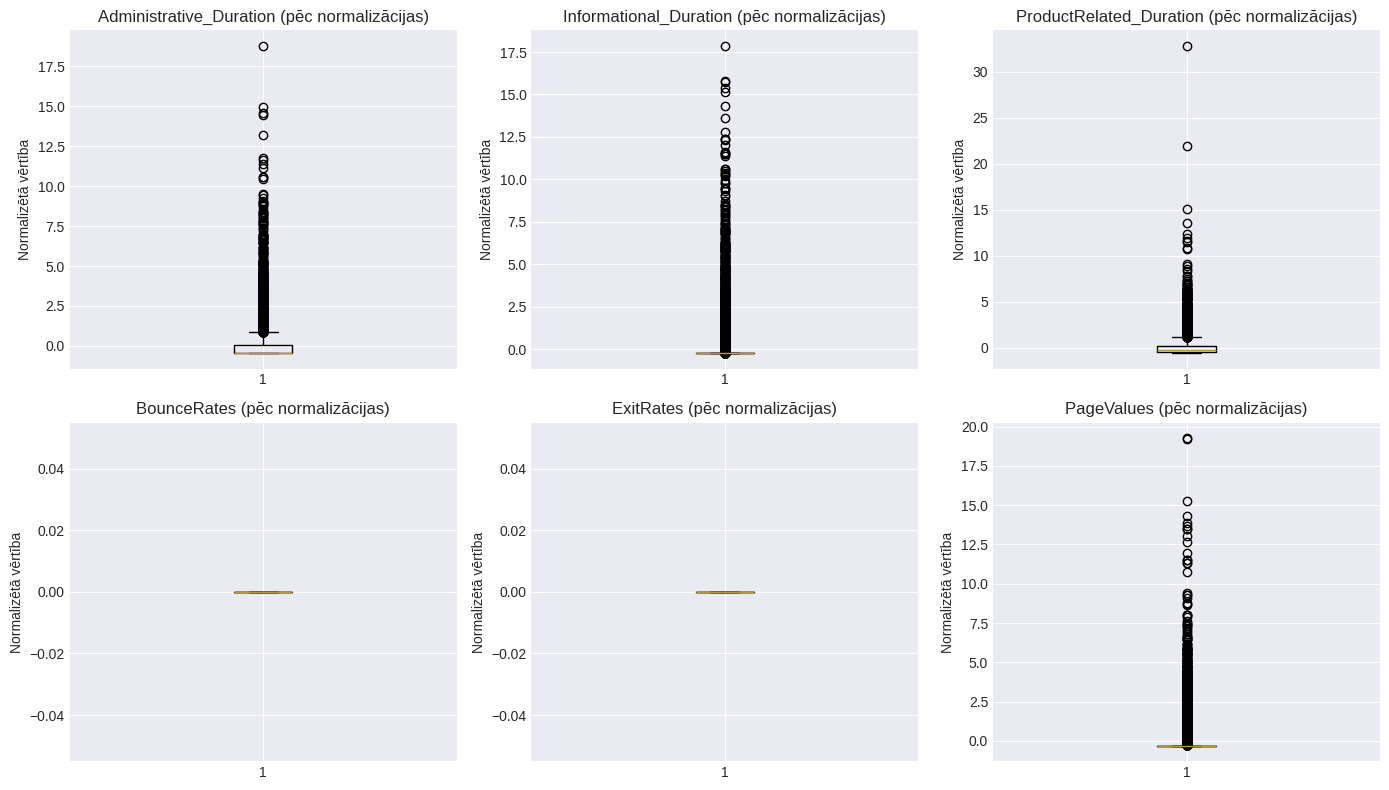

✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1


In [17]:
# Salīdzinājums:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sample_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
               'BounceRates', 'ExitRates', 'PageValues']

for idx, col in enumerate(sample_cols):
    if col in df.columns:
        axes[idx].boxplot(df[col], vert=True)
        axes[idx].set_title(f'{col} (pēc normalizācijas)')
        axes[idx].set_ylabel('Normalizētā vērtība')

plt.tight_layout()
plt.show()

print("✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1")


# 6.0  uzdevums. Jauna iezīme (Feature Engineering)

# 6.1. Jauna iezīmes izveide - TotalDuration

In [18]:
# 6.1. Jaunas iezīmes izveide
# Saskaitām visas laika kolonnas, lai redzētu kopējo sesijas ilgumu
df['TotalDuration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

print("✓ Jauna iezīme 'TotalDuration' izveidota")
print(f"Datu kopas forma tagad: {df.shape}")

✓ Jauna iezīme 'TotalDuration' izveidota
Datu kopas forma tagad: (12330, 28)


# 6.2. Paskaidrojums (Markdown šūna)

Ko nozīmē jaunā iezīme? parāda kopējo pavadīto laiku lapu
Kāpēc tā ir noderīga? Parāda cik ieinteresēts ir pircējs


# 6.3. Vizualizācija

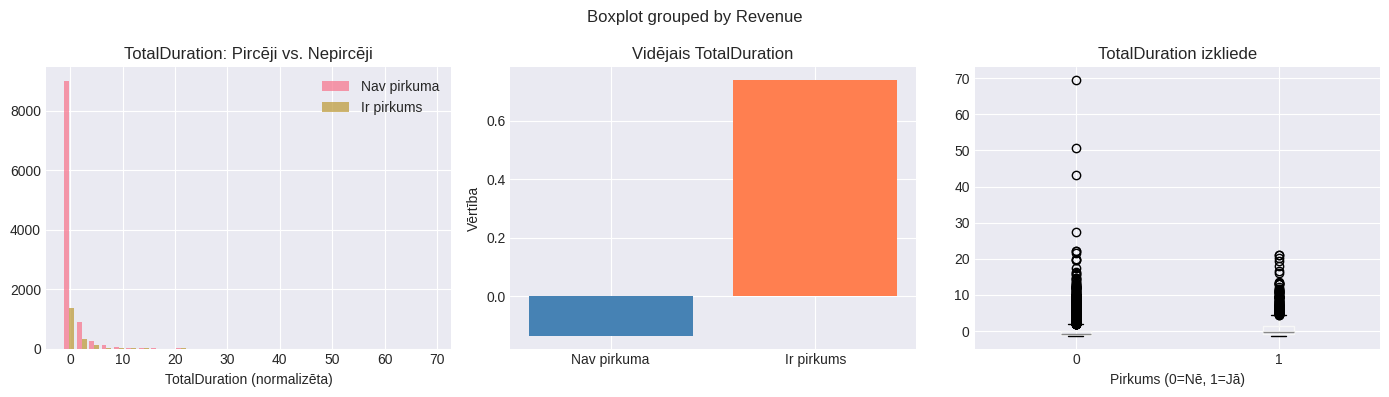

✓ Jaunā iezīme analizēta un vizualizēta


In [19]:
# Salīdzinājums: jaunā iezīme starp pircējiem un nepircējiem
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Piemērs ar TotalDuration (aprēķins ir redzams slaidos)
axes[0].hist([df[df['Revenue'] == 0]['TotalDuration'],
              df[df['Revenue'] == 1]['TotalDuration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('TotalDuration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('TotalDuration (normalizēta)')
axes[0].legend()

# Vidējie
axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
           [df[df['Revenue'] == 0]['TotalDuration'].mean(),
            df[df['Revenue'] == 1]['TotalDuration'].mean()],
           color=['steelblue', 'coral'])
axes[1].set_title('Vidējais TotalDuration')
axes[1].set_ylabel('Vērtība')

# Box plot
df.boxplot(column='TotalDuration', by='Revenue', ax=axes[2])
axes[2].set_title('TotalDuration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.tight_layout()
plt.show()

print("✓ Jaunā iezīme analizēta un vizualizēta")


# 7.0 uzdevums. Tīrās datu kopas saglabāšana

# 7.1. Datu saglabāšana

In [20]:
# Saglabā tīro datu kopu nākamajajiem uzdevumiem
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)

print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")


✓ Datu kopa saglabāta: shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 28


# 7.2. Pārbaude

In [21]:
# Pārbaudi, vai fails ir nolasāms
df_check = pd.read_csv(output_path)
print(f"✓ Fails pārbaudīts: {df_check.shape}")
print("Pirmās rindas:")
print(df_check.head(2))


✓ Fails pārbaudīts: (12330, 28)
Pirmās rindas:
   Administrative  Administrative_Duration  Informational  \
0       -0.696993                -0.456512      -0.396478   
1       -0.696993                -0.456512      -0.396478   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0               -0.244704       -0.691003                -0.624166   
1               -0.244704       -0.668518                -0.590720   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Jul  Month_June  \
0          0.0        0.0   -0.313368   -0.112463  ...  -0.190548   -0.154649   
1          0.0        0.0   -0.313368   -0.112463  ...  -0.190548   -0.154649   

   Month_Mar  Month_May  Month_Nov  Month_Oct  Month_Sep  VisitorType_Other  \
0  -0.427739  -0.612532  -0.566798  -0.215871  -0.194175          -0.083316   
1  -0.427739  -0.612532  -0.566798  -0.215871  -0.194175          -0.083316   

   VisitorType_Returning_Visitor  TotalDuration  
0                       0.

# 7.3. Rezumējums (Markdown šūna)
Uzraksti noslēdzošu rezumējumu:
Datu sagatavošanas rezumējums

**Identificētās problēmas:**
*   Sākotnējā datu kopā nebija trūkstošo vērtību, taču tika pārbaudīta to esamība.
*   Kategoriskās kolonnas (`Month`, `VisitorType`, `Weekend`, `Revenue`) nebija piemērotas tiešai ML modeļu apmācībai.
*   Skaitliskās kolonnas bija dažādās mērogtelpās, kas var ietekmēt modeļu veiktspēju.

**Veiktās darbības:**
*   Pārbaudītas trūkstošās vērtības — netika konstatētas.
*   **Kategorisko mainīgo kodēšana:**
    *   `Weekend` un `Revenue` (Boolean) kolonnas tika pārveidotas uz skaitliskām vērtībām (0 un 1).
    *   `Month` un `VisitorType` kolonnas, kurām ir vairākas unikālas kategorijas, tika kodētas ar One-Hot Encoding, lai izvairītos no mākslīgas secības noteikšanas.
*   **Skaitlisko kolonnu normalizācija:**
    *   Visas skaitliskās iezīmes (izņemot mērķa mainīgo `Revenue`) tika normalizētas, izmantojot `StandardScaler`, nodrošinot vidējo vērtību tuvu 0 un standartnovirzi tuvu 1.
*   **Jaunas iezīmes izveide (Feature Engineering):**
    *   Izveidota jauna iezīme `TotalDuration`, summējot visas ar sesijas ilgumu saistītās kolonnas (`Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration`), lai iegūtu kopējo laiku, ko lietotājs pavadījis vietnē. Šī iezīme parāda lietotāja ieinteresētību.

**Rezultāts:**
*   Datu kopa tika pilnībā sagatavota un attīrīta priekš mašīnmācīšanās modeļu apmācības.
*   Visas kolonnas ir skaitliskas un normalizētas, nodrošinot labāku veiktspēju ML algoritmiem.
*   Izveidota jauna, potenciāli noderīga iezīme, kas var uzlabot modeļa spēju prognozēt pirkuma iespējamību.

## B DAĻA: KLASIFIKĀCIJA

# 8.0 uzdevums. Sagatavo datus klasifikācijai

# 8.1. Ielādē tīro datu kopu un definē X, y

In [24]:
# Ielādē tikko sagatavoto tīro datu kopu
df = pd.read_csv('shoppers_clean.csv')

# Target mainīgais — vai klients veica pirkumu
y = df['Revenue']

# Features — visas pārējās kolonnas
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")


Features skaits: 27
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


# 8.2. Sadali datos treniņa un testa kopās

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā:\n{y_train.value_counts(normalize=True).round(3)}")


Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


# Markdown šūna: Paskaidro, kāpēc izmantojām stratify=y un kāpēc sadalījums 80/20 ir piemērots.
________________________________________


# 9. uzdevums. Trenē trīs klasifikācijas modeļus

# 9.1. Decision Tree

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Izveido un uztrenē modeli
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Prognozes uz testa kopas
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))


=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      2084
           1       0.66      0.61      0.64       382

    accuracy                           0.89      2466
   macro avg       0.79      0.78      0.79      2466
weighted avg       0.89      0.89      0.89      2466



# 9.2. Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))


=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.72      0.53      0.61       382

    accuracy                           0.89      2466
   macro avg       0.82      0.74      0.77      2466
weighted avg       0.89      0.89      0.89      2466



# 9.3. Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))


=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.72      0.35      0.47       382

    accuracy                           0.88      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.86      0.88      0.86      2466



# 10. uzdevums. Salīdzini modeļus

# 10.1. F1 score salīdzinājums

In [29]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))


            Modelis  F1 Score
      Decision Tree  0.635007
      Random Forest  0.608169
Logistic Regression  0.469965


# 10.2. Confusion matrices blakus

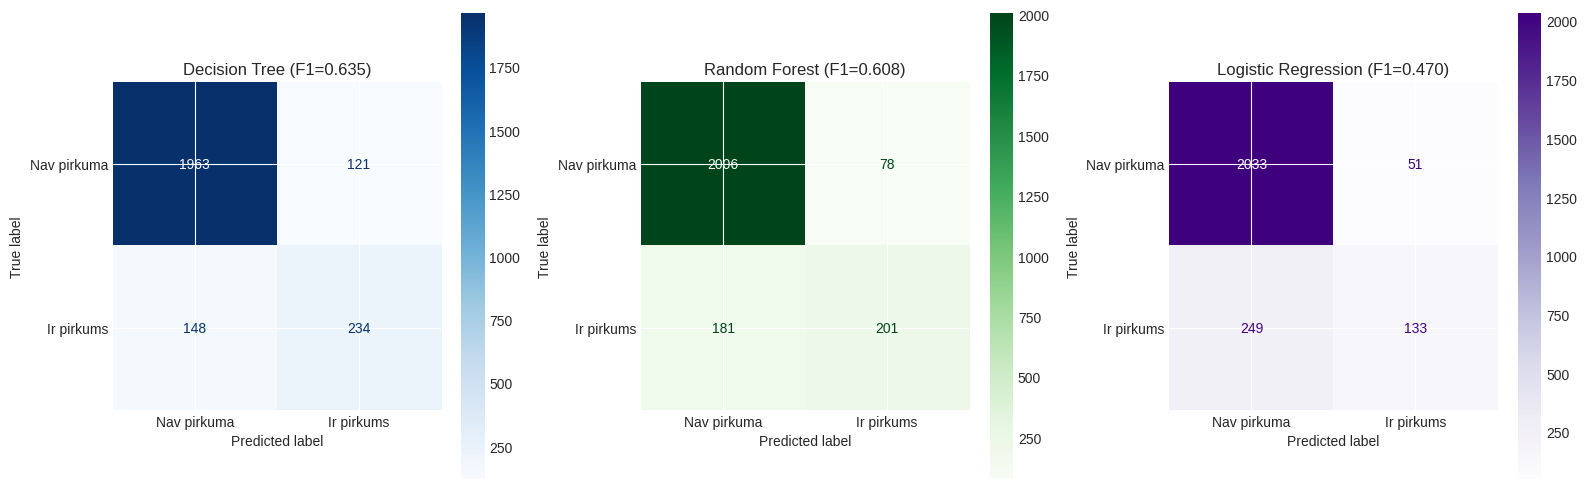

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()


# 10.3. Feature importance

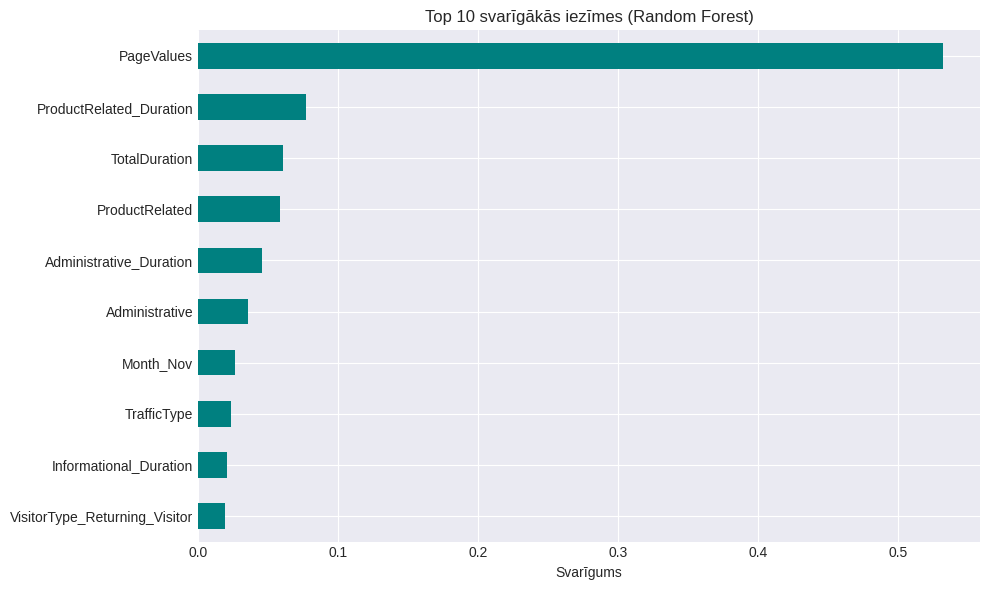

In [31]:
# Kuras iezīmes visvairāk ietekmē prognozi?
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 10.4. Secinājumi

**Kurš modelis ir labāks un kāpēc?**
Analizējot modeļu veiktspēju, īpaši pievēršot uzmanību F1 rādītājam, `Decision Tree` modelis (F1=0.635) uzrādīja vislabākos rezultātus starp visiem trim apmācītajiem modeļiem. `Random Forest` modelis (F1=0.608) sekoja tam ar nedaudz zemāku F1 rādītāju, bet joprojām demonstrēja labāku sniegumu nekā `Logistic Regression` (F1=0.470). Lai gan Random Forest bieži vien ir jaudīgāks, šajā gadījumā ar salīdzinoši nelielu datu kopu un maksimālo dziļuma ierobežojumu Decision Tree izrādījās efektīvāks. Logistic Regression, būdams vienkāršāks lineārais modelis, nespēja tik labi uztvert datu sarežģītās attiecības.

**Kāpēc šajā uzdevumā F1 score ir piemērotāks rādītājs nekā accuracy?**
Šajā uzdevumā datu kopa ir nelīdzsvarota — pirkumu (`Revenue = 1`) skaits ir ievērojami mazāks nekā pirkumu trūkums (`Revenue = 0`). Šādā situācijā `accuracy` (precizitāte) var būt mānīga, jo modelis, kas vienkārši prognozētu